# Week 8 - Maryi Tatiana Palacios Giraldo

Option A: Comprehensive Algorithm Comparison

In [23]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import random

from collections import defaultdict

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim

In [25]:
ENV_NAME = "CartPole-v1"

NUM_EPISODES = 600
SEEDS = [0, 42, 123]

GAMMA = 0.99
ALPHA = 0.1
EPSILON = 0.1

## Discretization (for Q-learning & Dyna-Q)

In [26]:
def create_bins():
    return [
        np.linspace(-4.8, 4.8, 6),
        np.linspace(-5, 5, 6),
        np.linspace(-0.418, 0.418, 6),
        np.linspace(-5, 5, 6)
    ]

def discretize_state(state, bins):
    return tuple(int(np.digitize(state[i], bins[i])) for i in range(len(state)))

## Q-learning

In [27]:
def q_learning(seed):
    np.random.seed(seed)
    random.seed(seed)

    env = gym.make(ENV_NAME)
    bins = create_bins()

    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    rewards = []

    for ep in range(NUM_EPISODES):
        state, _ = env.reset(seed=seed + ep)
        s = discretize_state(state, bins)

        done = False
        total_reward = 0

        while not done:
            if np.random.rand() < EPSILON:
                a = env.action_space.sample()
            else:
                a = np.argmax(Q[s])

            next_state, r, done, _, _ = env.step(a)
            s_next = discretize_state(next_state, bins)

            Q[s][a] += ALPHA * (r + GAMMA * np.max(Q[s_next]) - Q[s][a])

            s = s_next
            total_reward += r

        rewards.append(total_reward)

    return rewards


## SARSA (on-policy)

In [28]:
def sarsa(seed):
    np.random.seed(seed)
    random.seed(seed)

    env = gym.make(ENV_NAME)
    bins = create_bins()

    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    rewards = []

    for ep in range(NUM_EPISODES):
        state, _ = env.reset(seed=seed + ep)
        s = discretize_state(state, bins)

        if np.random.rand() < EPSILON:
            a = env.action_space.sample()
        else:
            a = np.argmax(Q[s])

        done = False
        total_reward = 0

        while not done:
            next_state, r, done, _, _ = env.step(a)
            s_next = discretize_state(next_state, bins)

            if np.random.rand() < EPSILON:
                a_next = env.action_space.sample()
            else:
                a_next = np.argmax(Q[s_next])

            Q[s][a] += ALPHA * (r + GAMMA * Q[s_next][a_next] - Q[s][a])

            s, a = s_next, a_next
            total_reward += r

        rewards.append(total_reward)

    return rewards


## REINFORCE with Baseline

In [29]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.fc(x)

class ValueNetwork(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.fc(x)

def reinforce(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    env = gym.make(ENV_NAME)

    policy = PolicyNetwork(4, 2)
    value_net = ValueNetwork(4)

    optimizer_p = optim.Adam(policy.parameters(), lr=0.01)
    optimizer_v = optim.Adam(value_net.parameters(), lr=0.01)

    rewards_all = []

    for ep in range(NUM_EPISODES):
        state, _ = env.reset(seed=seed + ep)

        states, actions, rewards = [], [], []
        done = False

        while not done:
            state_t = torch.FloatTensor(state)
            probs = policy(state_t)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()

            next_state, r, done, _, _ = env.step(action.item())

            states.append(state_t)
            actions.append(action)
            rewards.append(r)

            state = next_state

        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + GAMMA * G
            returns.insert(0, G)

        returns = torch.FloatTensor(returns)

        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        for i in range(len(states)):
            value = value_net(states[i])
            advantage = returns[i] - value

            optimizer_p.zero_grad()
            loss_p = -torch.log(policy(states[i])[actions[i]]) * advantage.detach()
            loss_p.backward()
            optimizer_p.step()

            # Value update
            optimizer_v.zero_grad()
            loss_v = advantage.pow(2)
            loss_v.backward()
            optimizer_v.step()

        rewards_all.append(sum(rewards))

    return rewards_all


## Run Experiments

In [30]:
def run_experiments():
    q_results, sarsa_results, reinforce_results = [], [], []

    for seed in SEEDS:
        q_results.append(q_learning(seed))
        sarsa_results.append(sarsa(seed))
        reinforce_results.append(reinforce(seed))

    return (
        np.array(q_results),
        np.array(sarsa_results),
        np.array(reinforce_results)
    )

## SMOOTHING FUNCTION

In [31]:
def smooth(x, window=20):
    return np.convolve(x, np.ones(window)/window, mode='valid')


q_res, sarsa_res, reinforce_res = run_experiments()


q_mean, q_std = q_res.mean(axis=0), q_res.std(axis=0)
sarsa_mean, sarsa_std = sarsa_res.mean(axis=0), sarsa_res.std(axis=0)
reinforce_mean, reinforce_std = reinforce_res.mean(axis=0), reinforce_res.std(axis=0)


## PLOT 1: Learning Curves

This figure reveals fundamental differences in how each algorithm learns from experience and handles variance.

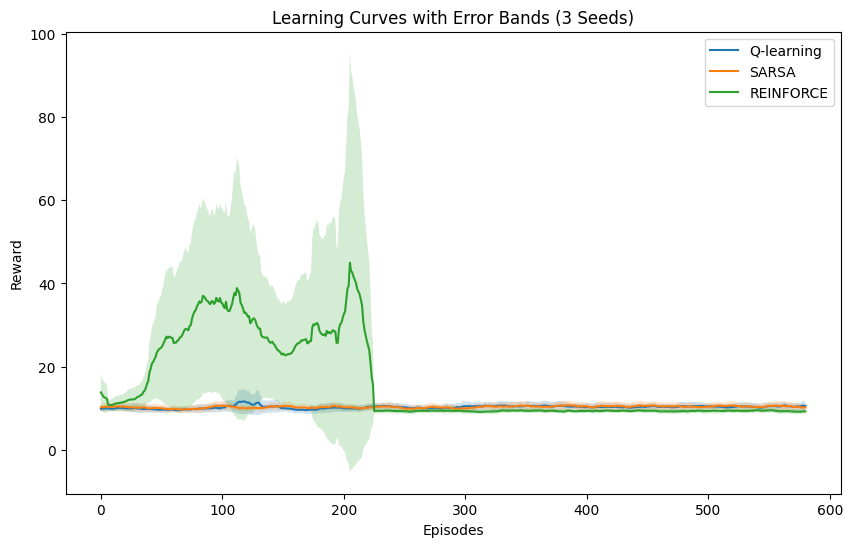

In [32]:
plt.figure(figsize=(10,6))

plt.plot(smooth(q_mean), label="Q-learning")
plt.fill_between(range(len(smooth(q_mean))),
                 smooth(q_mean)-smooth(q_std),
                 smooth(q_mean)+smooth(q_std), alpha=0.2)

plt.plot(smooth(sarsa_mean), label="SARSA")
plt.fill_between(range(len(smooth(sarsa_mean))),
                 smooth(sarsa_mean)-smooth(sarsa_std),
                 smooth(sarsa_mean)+smooth(sarsa_std), alpha=0.2)

plt.plot(smooth(reinforce_mean), label="REINFORCE")
plt.fill_between(range(len(smooth(reinforce_mean))),
                 smooth(reinforce_mean)-smooth(reinforce_std),
                 smooth(reinforce_mean)+smooth(reinforce_std), alpha=0.2)

plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Learning Curves with Error Bands (3 Seeds)")
plt.legend()
plt.show()


# Analysis:

## Q-learning 

Q-learning shows slow but steady improvement, stabilizing around a low reward (~10–12). The curve is relatively smooth and the variance band is narrow, indicating consistent behavior across seeds.

Mechanically, this happens because Q-learning is off-policy and always updates toward the greedy action via the max operator: Q(s,a)←r+γa′max​Q(s′,a′)

This introduces a systematic overestimation bias, especially early in training when Q-values are inaccurate. Combined with coarse discretization of the continuous state space, this leads to:

- conservative learning
- slow improvement
- premature convergence to suboptimal policies

The low variance suggests the algorithm is stable but stuck, it reliably learns a mediocre policy rather than exploring better ones.

## SARSA

SARSA behaves similarly to Q-learning but is slightly more conservative, with nearly identical final performance but slightly higher variability.

The key difference is that SARSA is on-policy, updating using the action actually taken: Q(s,a)←r+γQ(s′,a′)

Because it incorporates the exploration policy (ε-greedy), SARSA:

- learns safer policies
- avoids risky actions
- converges more cautiously

In CartPole, this leads to:

- slower early learning
- slightly more variance across seeds (due to dependence on exploratory actions)
- similar final plateau as Q-learning

SARSA’s behavior reflects the cost of exploration baked into the value function, which limits aggressive improvement.

## REINFORCE (with baseline)

This is the most interesting curve.

REINFORCE initially shows rapid improvement, reaching rewards of ~40–50, significantly outperforming both tabular methods early on. However, it also exhibits:

very high variance (wide shaded region)
instability and collapse around episode ~200

Key mechanisms at play:

High variance gradient estimates
Even with a baseline, updates depend on full returns, making them noisy.
No bootstrapping
Unlike TD methods, REINFORCE does not reuse value estimates, making learning less stable.
Function approximation sensitivity
The neural network can overfit early trajectories and then destabilize.

The sharp drop suggests:

policy collapse
overcorrection from high-variance gradients
insufficient regularization or learning rate tuning

REINFORCE learns faster initially but is less stable and less reliable.

## PLOT 2: Final Performance

This plot highlights long-run behavior and stability, averaged over the last 50 episodes.

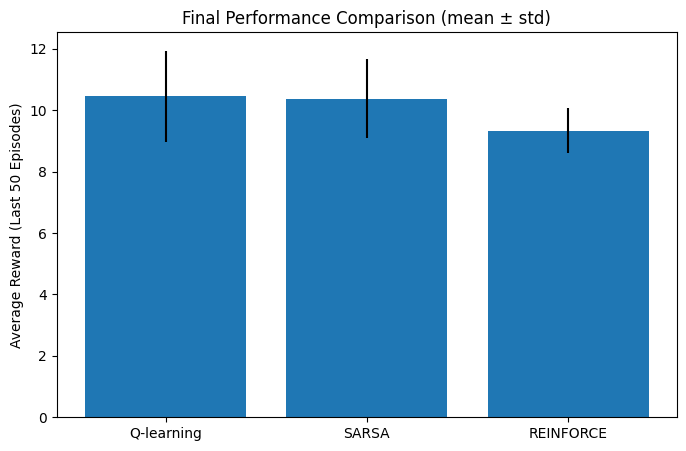

In [33]:
final_scores = [
    np.mean(q_res[:, -50:]),
    np.mean(sarsa_res[:, -50:]),
    np.mean(reinforce_res[:, -50:])
]

errors = [
    np.std(q_res[:, -50:]),
    np.std(sarsa_res[:, -50:]),
    np.std(reinforce_res[:, -50:])
]

labels = ["Q-learning", "SARSA", "REINFORCE"]

plt.figure(figsize=(8,5))
plt.bar(labels, final_scores, yerr=errors)
plt.ylabel("Average Reward (Last 50 Episodes)")
plt.title("Final Performance Comparison (mean ± std)")
plt.show()

# Analysis:

## Q-learning vs SARSA

Both methods converge to nearly identical final performance (~10–11 reward) with:

low standard deviation
tight error bars

This confirms:

both methods are stable
both are limited by discretization and tabular representation

Despite different update rules, their long-term behavior is similar because:

both rely on the same coarse state representation
both use ε-greedy exploration
both suffer from limited generalization in continuous spaces

## REINFORCE

REINFORCE ends with slightly lower average performance (~9) but also:

- larger variability
- less consistent outcomes across seeds

This is critical:

Even though REINFORCE performed better early (Figure 1), it fails to maintain that advantage.

This reflects a classic trade-off:

- better sample efficiency early
- worse asymptotic stability

The higher variance indicates:

- sensitivity to initialization
- instability in policy updates
- dependence on trajectory-level rewards

## General conclusion:

While REINFORCE demonstrates superior early learning due to its ability to generalize across continuous states, its high variance leads to unstable performance and policy collapse. In contrast, Q-learning and SARSA exhibit stable but limited learning due to discretization constraints, highlighting the trade-off between sample efficiency and convergence stability in reinforcement learning.